## Classification on NSL-KDD Dataset, Rare Types

NSL-KDD Rare Attacks Classification
Loading datasets...
Training data shape: (67498, 45)
Testing data shape: (11947, 45)

Dataset Info:
Training samples: 67,498
Testing samples: 11,947
Total features: 45

Columns: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'attack_type', 'difficulty_level', 'label', 'sub_label']


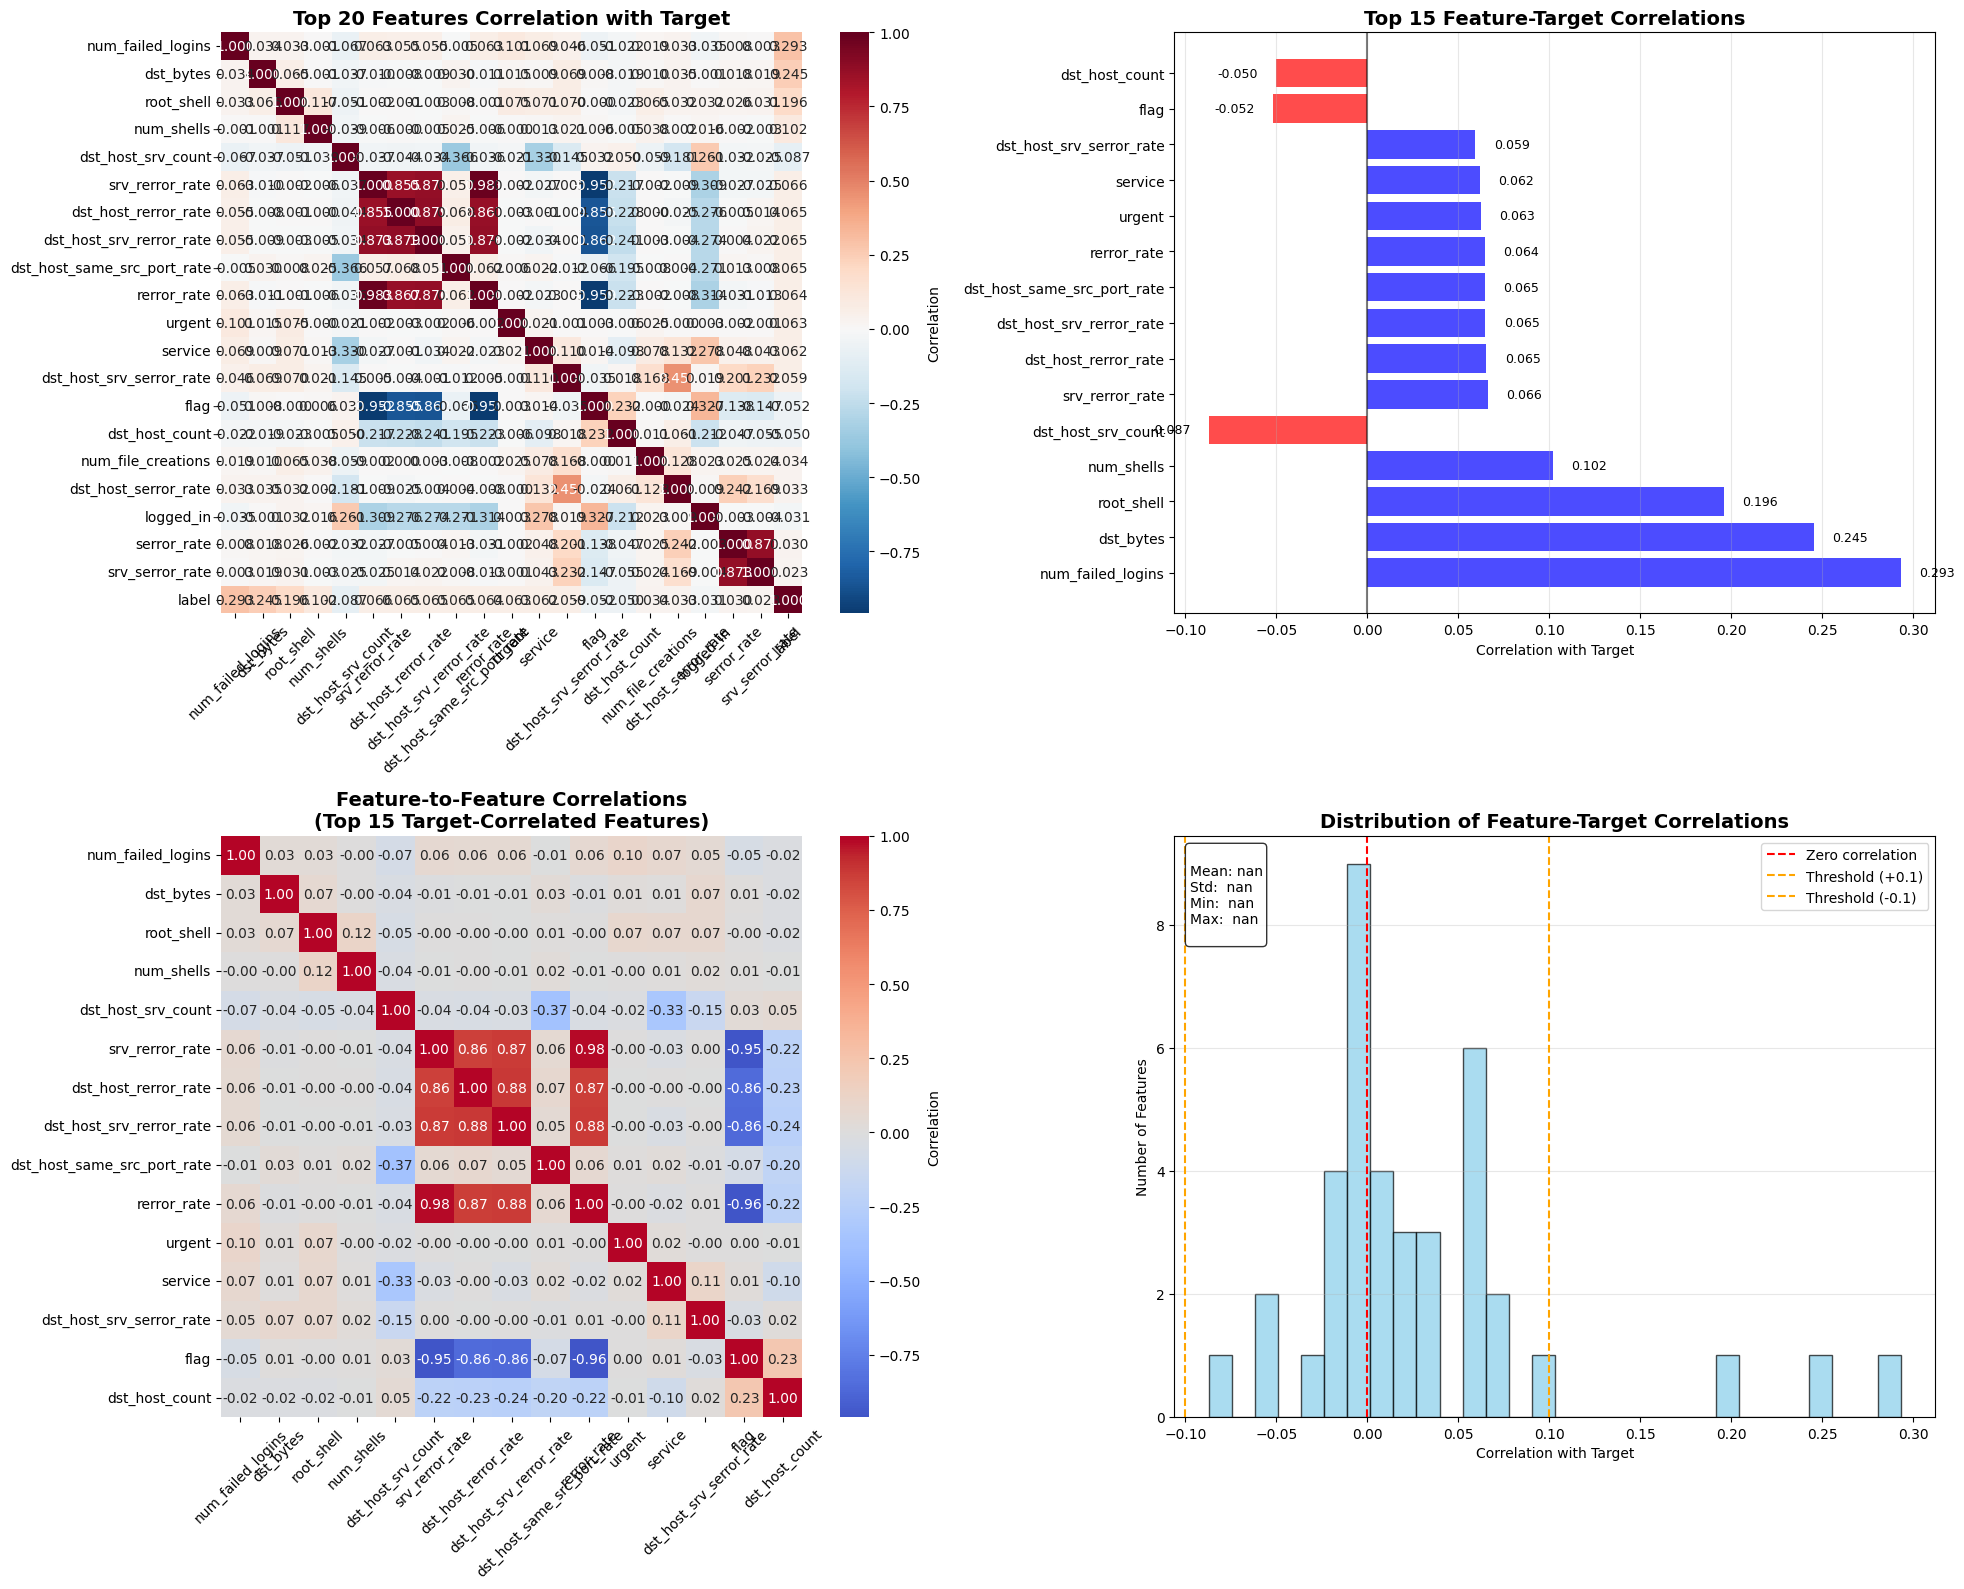


CORRELATION-BASED FEATURE INSIGHTS
📊 CORRELATION SUMMARY:
Total features analyzed: 41
Positively correlated: 24 features
Negatively correlated: 15 features
Strongly correlated (|r| > 0.1): 4 features

🔺 TOP POSITIVE CORRELATIONS (higher values → more likely malicious):
  • num_failed_logins        :  0.2931
  • dst_bytes                :  0.2454
  • root_shell               :  0.1958
  • num_shells               :  0.1018
  • srv_rerror_rate          :  0.0665

🔻 TOP NEGATIVE CORRELATIONS (higher values → more likely normal):
  • dst_host_srv_count       : -0.0871
  • flag                     : -0.0520
  • dst_host_count           : -0.0500
  • logged_in                : -0.0314
  • count                    : -0.0174

💡 FEATURE ENGINEERING INSIGHTS:
  • Top 5 impact features for interaction terms: ['num_failed_logins', 'dst_bytes', 'root_shell', 'num_shells', 'dst_host_srv_count']
    → Consider creating interaction features between these
  • 15 multicollinear feature pairs detected
 

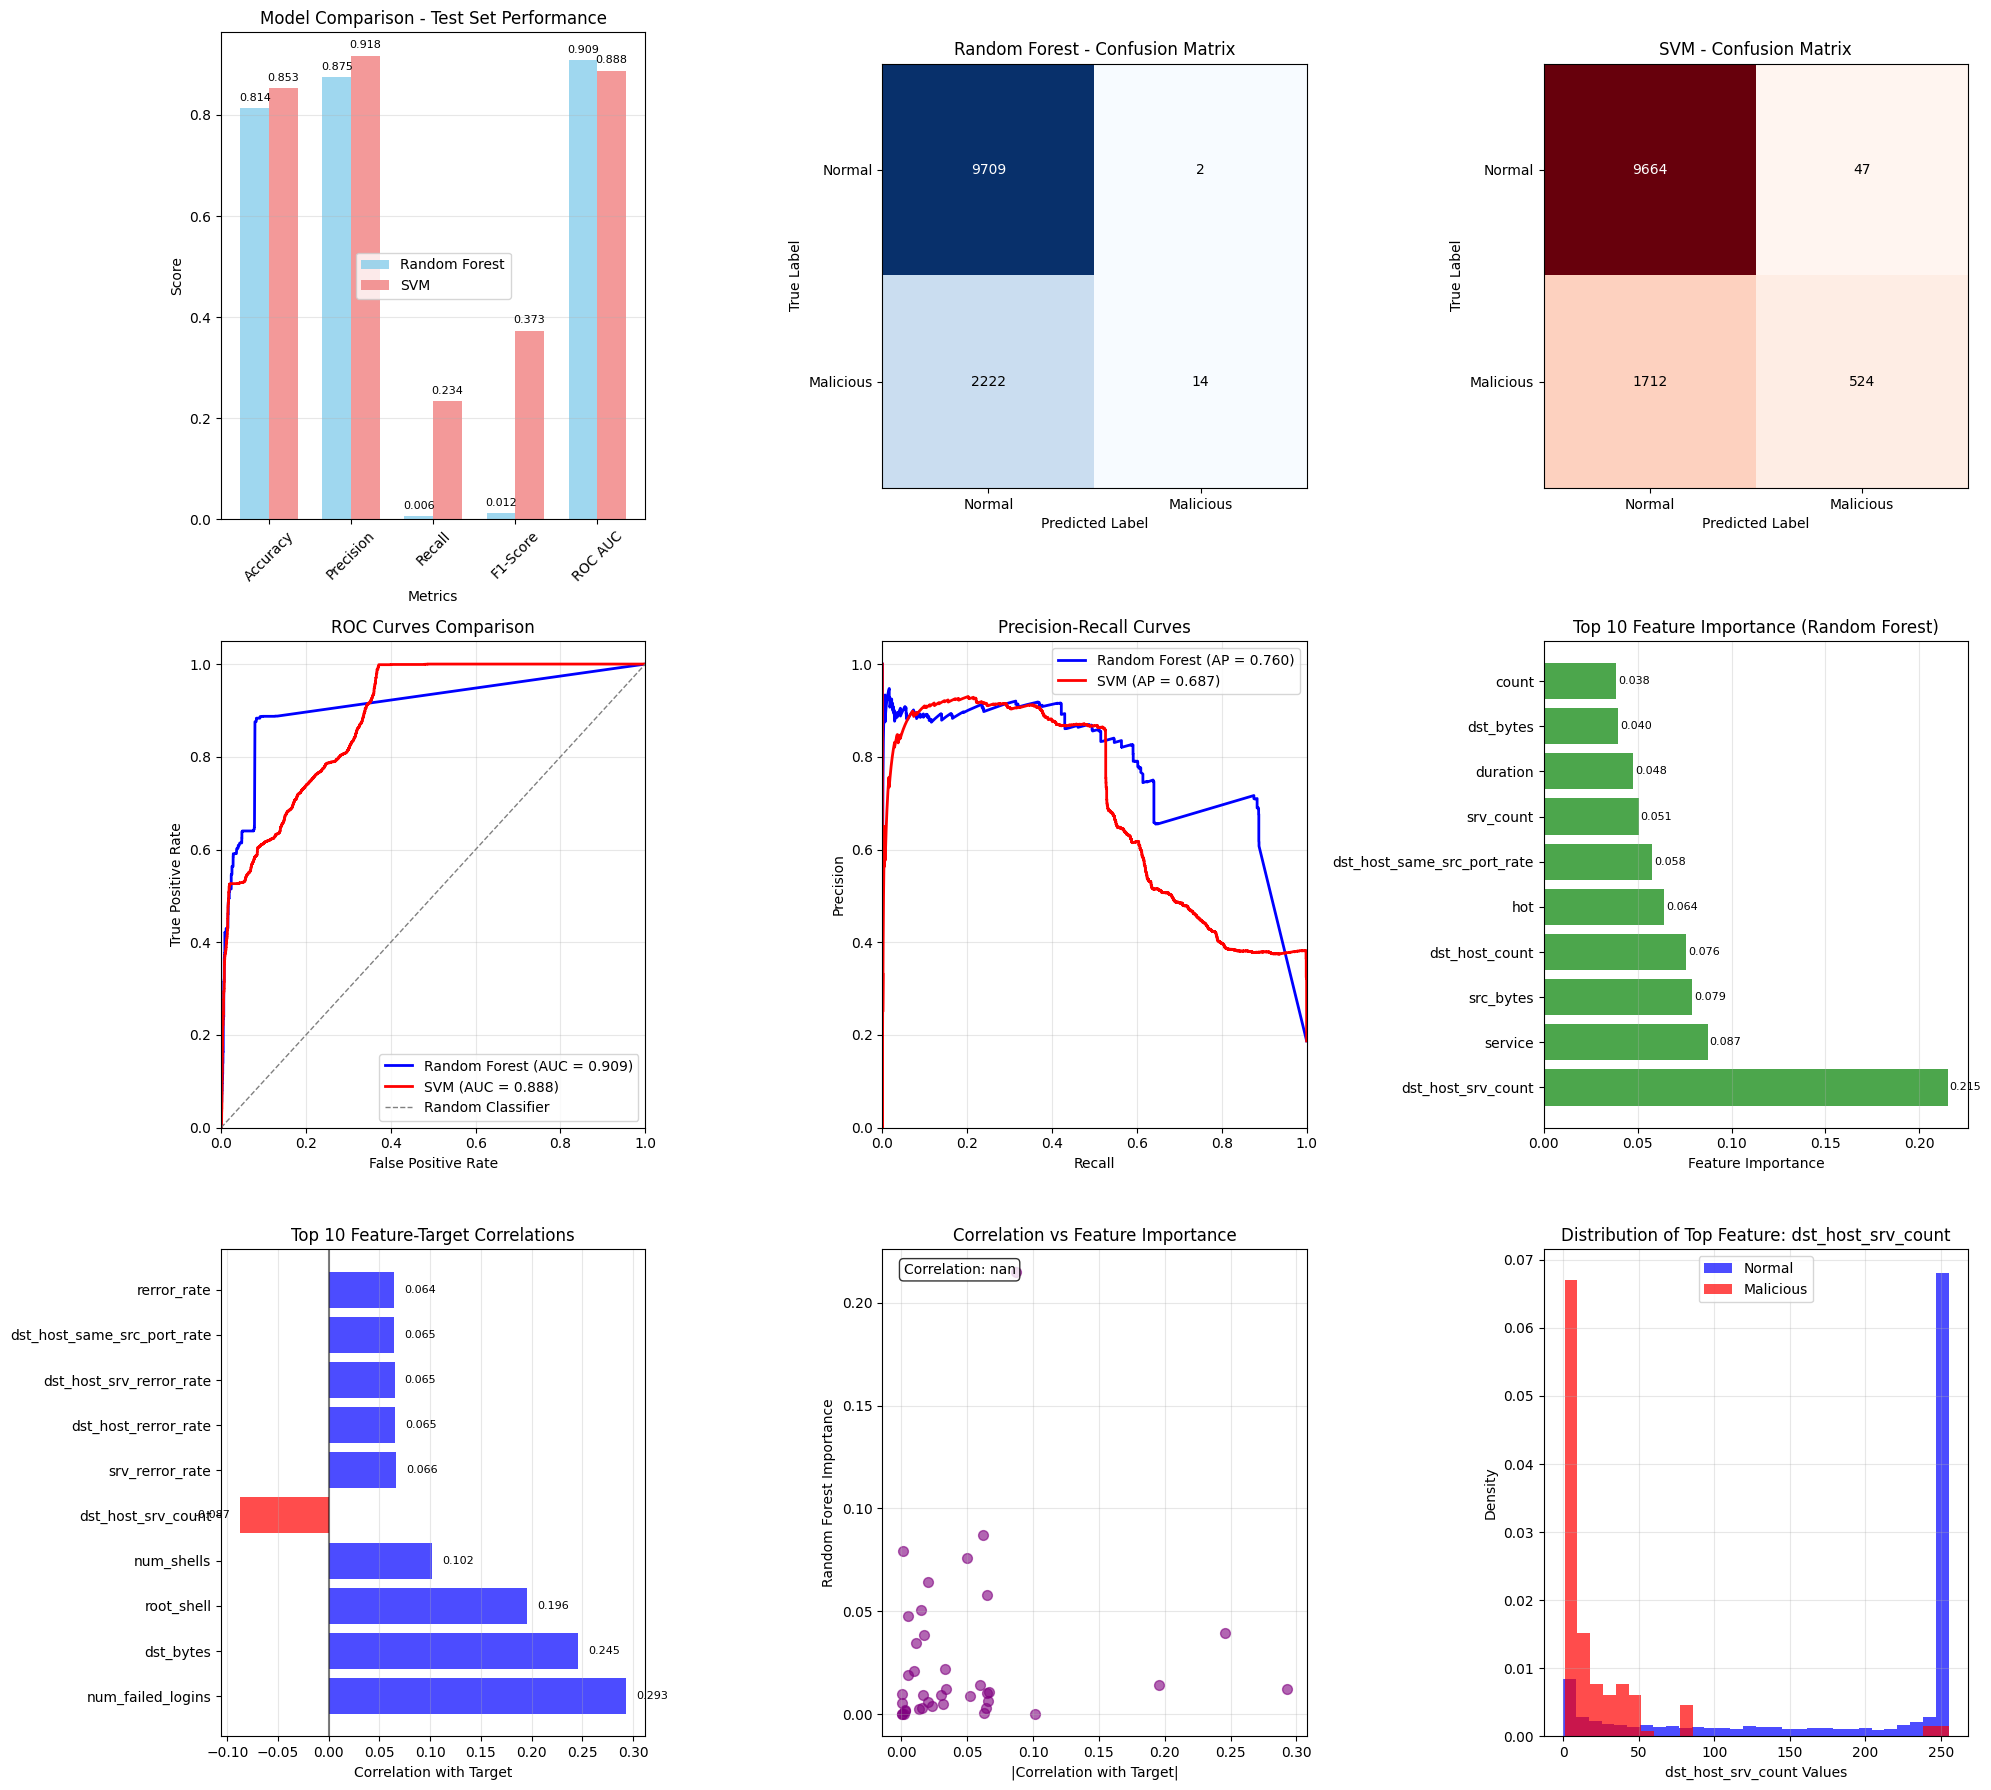


FINAL SUMMARY

📊 DATASET SUMMARY:
Training samples: 67,498 (Normal: 67,343, Malicious: 155)
Testing samples:  11,947 (Normal: 9,711, Malicious: 2,236)
Features used: 41
Imbalance ratio: 4.3:1 (Normal:Malicious)

🎯 MODEL PERFORMANCE COMPARISON (Test Set):
Metric          Random Forest   SVM             Winner    
-------------------------------------------------------
Accuracy        0.8138          0.8528          SVM       
Precision       0.8750          0.9177          SVM       
Recall          0.0063          0.2343          SVM       
F1-Score        0.0124          0.3734          SVM       
ROC AUC         0.9089          0.8879          RF        

🏆 OVERALL WINNER:
SVM performs better (4/5 metrics)

🔍 KEY INSIGHTS:
• Random Forest F1-Score: 0.0124
• SVM F1-Score: 0.3734
• Best model for rare attack detection: SVM
• Top feature: dst_host_srv_count (importance: 0.2152)
• Rare attack detection rate: RF=0.6%, SVM=23.4%

✅ Analysis completed successfully!
Both models have been tr

In [3]:
# NSL-KDD Rare Attacks Classification with Random Forest & SVM
# ============================================================
# Binary classification: Normal (0) vs Malicious (1) using R2L & U2R attacks
# Models: Random Forest and SVM
# Dataset: Common rare attacks only (present in both train and test)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, 
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("NSL-KDD Rare Attacks Classification")
print("=" * 50)
print("Loading datasets...")

# ============================================================
# 1. DATA LOADING AND EXPLORATION
# ============================================================

# Load datasets
train_data = pd.read_csv("../raw/nsl_kdd_rare_train.csv.gz", compression='gzip')
test_data = pd.read_csv("../raw/nsl_kdd_rare_test.csv.gz", compression='gzip')

print(f"Training data shape: {train_data.shape}")
print(f"Testing data shape: {test_data.shape}")

# Display basic info
print("\nDataset Info:")
print(f"Training samples: {len(train_data):,}")
print(f"Testing samples: {len(test_data):,}")
print(f"Total features: {train_data.shape[1]}")

# Check columns
print(f"\nColumns: {list(train_data.columns)}")

# ============================================================
# 2. DATA PREPROCESSING
# ============================================================

print("\n" + "=" * 50)
print("DATA PREPROCESSING")
print("=" * 50)

# Define columns to exclude from features
exclude_columns = ['label', 'sub_label', 'attack_type', 'difficulty_level']

# Get feature columns (all except excluded ones)
feature_columns = [col for col in train_data.columns if col not in exclude_columns]
print(f"Feature columns ({len(feature_columns)}): {feature_columns[:10]}...")

# Extract features and labels
X_train = train_data[feature_columns].copy()
y_train = train_data['label'].copy()
X_test = test_data[feature_columns].copy()
y_test = test_data['label'].copy()

print(f"\nFeatures shape: Train {X_train.shape}, Test {X_test.shape}")
print(f"Labels shape: Train {y_train.shape}, Test {y_test.shape}")

# Check class distribution
print(f"\nClass Distribution:")
print(f"Training set:")
train_dist = y_train.value_counts().sort_index()
for label, count in train_dist.items():
    label_name = "Normal" if label == 0 else "Malicious"
    print(f"  {label_name} ({label}): {count:,} ({count/len(y_train)*100:.2f}%)")

print(f"Testing set:")
test_dist = y_test.value_counts().sort_index()
for label, count in test_dist.items():
    label_name = "Normal" if label == 0 else "Malicious"
    print(f"  {label_name} ({label}): {count:,} ({count/len(y_test)*100:.2f}%)")

# Identify categorical and numerical columns
categorical_columns = []
numerical_columns = []

for col in feature_columns:
    if X_train[col].dtype == 'object':
        categorical_columns.append(col)
    else:
        numerical_columns.append(col)

print(f"\nCategorical columns ({len(categorical_columns)}): {categorical_columns}")
print(f"Numerical columns ({len(numerical_columns)}): {len(numerical_columns)} columns")

# ============================================================
# 3. FEATURE ENCODING
# ============================================================

print("\nEncoding categorical features...")

# Create copies for processing
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

# Label encode categorical variables
label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    
    # Fit on combined data to ensure consistent encoding
    combined_values = pd.concat([X_train[col], X_test[col]], ignore_index=True)
    le.fit(combined_values)
    
    # Transform both sets
    X_train_processed[col] = le.transform(X_train[col])
    X_test_processed[col] = le.transform(X_test[col])
    
    label_encoders[col] = le
    
    print(f"  {col}: {len(le.classes_)} unique values")

print("✓ Categorical encoding completed")

# Check for any remaining non-numeric data
print(f"\nData types after encoding:")
print(f"Non-numeric columns: {X_train_processed.select_dtypes(exclude=[np.number]).columns.tolist()}")

# ============================================================
# 4. CORRELATION ANALYSIS & FEATURE ENGINEERING
# ============================================================

print("\n" + "=" * 50)
print("CORRELATION ANALYSIS")
print("=" * 50)

# Create correlation matrix with labels
print("Computing correlation matrix...")

# Combine features with labels for correlation analysis
correlation_data = X_train_processed.copy()
correlation_data['label'] = y_train

# Compute correlation matrix
correlation_matrix = correlation_data.corr()

# Get correlation with target variable (label)
target_correlation = correlation_matrix['label'].drop('label').sort_values(key=abs, ascending=False)

print(f"\nTop 15 Features Most Correlated with Target (Label):")
print("-" * 60)
print(f"{'Feature':<25} {'Correlation':<12} {'Abs Correlation':<15}")
print("-" * 60)

for feature, corr in target_correlation.head(15).items():
    print(f"{feature:<25} {corr:<12.4f} {abs(corr):<15.4f}")

# Identify highly correlated features
high_corr_threshold = 0.1  # Adjust threshold as needed
highly_correlated_features = target_correlation[abs(target_correlation) > high_corr_threshold]

print(f"\nFeatures with |correlation| > {high_corr_threshold}:")
print(f"Found {len(highly_correlated_features)} features")
for feature, corr in highly_correlated_features.items():
    direction = "positive" if corr > 0 else "negative"
    print(f"  • {feature:<25}: {corr:>7.4f} ({direction})")

# Find feature-to-feature correlations (multicollinearity)
print(f"\nChecking for multicollinearity...")
feature_corr_matrix = X_train_processed.corr()

# Find pairs of highly correlated features
multicollinearity_threshold = 0.8
high_corr_pairs = []

for i in range(len(feature_corr_matrix.columns)):
    for j in range(i+1, len(feature_corr_matrix.columns)):
        corr_value = feature_corr_matrix.iloc[i, j]
        if abs(corr_value) > multicollinearity_threshold:
            high_corr_pairs.append((
                feature_corr_matrix.columns[i], 
                feature_corr_matrix.columns[j], 
                corr_value
            ))

if high_corr_pairs:
    print(f"Found {len(high_corr_pairs)} highly correlated feature pairs (|corr| > {multicollinearity_threshold}):")
    for feat1, feat2, corr in high_corr_pairs:
        print(f"  • {feat1} ↔ {feat2}: {corr:.4f}")
else:
    print(f"No highly correlated feature pairs found (threshold: {multicollinearity_threshold})")

# ============================================================
# 4.1 CORRELATION HEATMAPS VISUALIZATION
# ============================================================

print(f"\nCreating correlation heatmaps...")

# Create comprehensive correlation visualizations
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 1. Target correlation heatmap (top features)
top_features_for_heatmap = target_correlation.head(20).index.tolist()
target_corr_data = correlation_data[top_features_for_heatmap + ['label']]
target_corr_matrix = target_corr_data.corr()

sns.heatmap(target_corr_matrix, 
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            fmt='.3f',
            square=True,
            ax=axes[0,0],
            cbar_kws={'label': 'Correlation'})
axes[0,0].set_title('Top 20 Features Correlation with Target', fontsize=14, fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].tick_params(axis='y', rotation=0)

# 2. Feature-to-target correlation bar plot
target_corr_abs = target_correlation.head(15)
colors = ['red' if x < 0 else 'blue' for x in target_corr_abs.values]

axes[0,1].barh(range(len(target_corr_abs)), target_corr_abs.values, color=colors, alpha=0.7)
axes[0,1].set_yticks(range(len(target_corr_abs)))
axes[0,1].set_yticklabels(target_corr_abs.index)
axes[0,1].set_xlabel('Correlation with Target')
axes[0,1].set_title('Top 15 Feature-Target Correlations', fontsize=14, fontweight='bold')
axes[0,1].grid(axis='x', alpha=0.3)
axes[0,1].axvline(x=0, color='black', linestyle='-', alpha=0.5)

# Add value labels
for i, v in enumerate(target_corr_abs.values):
    axes[0,1].text(v + (0.01 if v >= 0 else -0.01), i, f'{v:.3f}', 
                   va='center', ha='left' if v >= 0 else 'right', fontsize=9)

# 3. Feature-to-feature correlation heatmap (top correlated features)
# Select features that are most correlated with target
selected_features = target_correlation.head(15).index.tolist()
feature_subset_corr = X_train_processed[selected_features].corr()

sns.heatmap(feature_subset_corr, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',
            square=True,
            ax=axes[1,0],
            cbar_kws={'label': 'Correlation'})
axes[1,0].set_title('Feature-to-Feature Correlations\n(Top 15 Target-Correlated Features)', 
                   fontsize=14, fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].tick_params(axis='y', rotation=0)

# 4. Correlation distribution histogram
all_correlations = target_correlation.values
axes[1,1].hist(all_correlations, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[1,1].axvline(x=0, color='red', linestyle='--', label='Zero correlation')
axes[1,1].axvline(x=high_corr_threshold, color='orange', linestyle='--', 
                 label=f'Threshold (+{high_corr_threshold})')
axes[1,1].axvline(x=-high_corr_threshold, color='orange', linestyle='--', 
                 label=f'Threshold (-{high_corr_threshold})')
axes[1,1].set_xlabel('Correlation with Target')
axes[1,1].set_ylabel('Number of Features')
axes[1,1].set_title('Distribution of Feature-Target Correlations', fontsize=14, fontweight='bold')
axes[1,1].legend()
axes[1,1].grid(axis='y', alpha=0.3)

# Add statistics text
corr_stats = f"""
Mean: {np.mean(all_correlations):.3f}
Std:  {np.std(all_correlations):.3f}
Min:  {np.min(all_correlations):.3f}
Max:  {np.max(all_correlations):.3f}
"""
axes[1,1].text(0.02, 0.98, corr_stats, transform=axes[1,1].transAxes, 
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# ============================================================
# 4.2 FEATURE SELECTION BASED ON CORRELATION
# ============================================================

print(f"\n" + "=" * 50)
print("CORRELATION-BASED FEATURE INSIGHTS")
print("=" * 50)

# Analyze positive vs negative correlations
positive_corrs = target_correlation[target_correlation > 0]
negative_corrs = target_correlation[target_correlation < 0]

print(f"📊 CORRELATION SUMMARY:")
print(f"Total features analyzed: {len(target_correlation)}")
print(f"Positively correlated: {len(positive_corrs)} features")
print(f"Negatively correlated: {len(negative_corrs)} features")
print(f"Strongly correlated (|r| > {high_corr_threshold}): {len(highly_correlated_features)} features")

if len(positive_corrs) > 0:
    print(f"\n🔺 TOP POSITIVE CORRELATIONS (higher values → more likely malicious):")
    for feature, corr in positive_corrs.head(5).items():
        print(f"  • {feature:<25}: {corr:>7.4f}")

if len(negative_corrs) > 0:
    print(f"\n🔻 TOP NEGATIVE CORRELATIONS (higher values → more likely normal):")
    for feature, corr in negative_corrs.head(5).items():
        print(f"  • {feature:<25}: {corr:>7.4f}")

# Feature engineering suggestions
print(f"\n💡 FEATURE ENGINEERING INSIGHTS:")

# Check if categorical features are in top correlations
categorical_in_top = [feat for feat in target_correlation.head(10).index if feat in categorical_columns]
if categorical_in_top:
    print(f"  • High-impact categorical features: {categorical_in_top}")
    print(f"    → Consider one-hot encoding or advanced categorical encoding")

# Check for potential feature combinations
high_impact_features = target_correlation.head(5).index.tolist()
print(f"  • Top 5 impact features for interaction terms: {high_impact_features}")
print(f"    → Consider creating interaction features between these")

# Multicollinearity recommendations
if high_corr_pairs:
    print(f"  • {len(high_corr_pairs)} multicollinear feature pairs detected")
    print(f"    → Consider removing one feature from each pair or using PCA")
else:
    print(f"  • No significant multicollinearity detected")
    print(f"    → All features can be safely used")

# ============================================================
# 4.3 FEATURE SCALING
# ============================================================

print("\n" + "=" * 50)
print("FEATURE SCALING")
print("=" * 50)

print("Scaling features for SVM...")

# Scale features (important for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

print("✓ Feature scaling completed")
print(f"Scaled features shape: Train {X_train_scaled.shape}, Test {X_test_scaled.shape}")

# Show scaling statistics
print(f"\nScaling Statistics:")
print(f"Original feature range: [{X_train_processed.min().min():.3f}, {X_train_processed.max().max():.3f}]")
print(f"Scaled feature range: [{X_train_scaled.min():.3f}, {X_train_scaled.max():.3f}]")
print(f"Scaled feature mean: {X_train_scaled.mean():.6f}")
print(f"Scaled feature std: {X_train_scaled.std():.6f}")

# ============================================================
# 5. MODEL TRAINING - RANDOM FOREST
# ============================================================

print("\n" + "=" * 50)
print("RANDOM FOREST CLASSIFIER")
print("=" * 50)

# Train Random Forest (doesn't need scaled features)
print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight='balanced'  # Handle class imbalance
)

rf_model.fit(X_train_processed, y_train)
print("✓ Random Forest training completed")

# Predictions
rf_train_pred = rf_model.predict(X_train_processed)
rf_test_pred = rf_model.predict(X_test_processed)
rf_train_proba = rf_model.predict_proba(X_train_processed)[:, 1]
rf_test_proba = rf_model.predict_proba(X_test_processed)[:, 1]

print("✓ Random Forest predictions completed")

# ============================================================
# 6. MODEL TRAINING - SVM
# ============================================================

print("\n" + "=" * 50)
print("SVM CLASSIFIER")
print("=" * 50)

# Train SVM (using scaled features)
print("Training SVM...")

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=RANDOM_STATE,
    probability=True,  # Enable probability estimates
    class_weight='balanced'  # Handle class imbalance
)

svm_model.fit(X_train_scaled, y_train)
print("✓ SVM training completed")

# Predictions
svm_train_pred = svm_model.predict(X_train_scaled)
svm_test_pred = svm_model.predict(X_test_scaled)
svm_train_proba = svm_model.predict_proba(X_train_scaled)[:, 1]
svm_test_proba = svm_model.predict_proba(X_test_scaled)[:, 1]

print("✓ SVM predictions completed")

# ============================================================
# 7. MODEL EVALUATION
# ============================================================

print("\n" + "=" * 50)
print("MODEL EVALUATION")
print("=" * 50)

def evaluate_model(y_true, y_pred, y_proba, model_name, dataset_name):
    """
    Comprehensive model evaluation with detailed explanations
    
    Args:
        y_true: True labels from the dataset
        y_pred: Predicted labels from the model
        y_proba: Predicted probabilities from the model
        model_name: Name of the model (Random Forest or SVM)
        dataset_name: Name of the dataset (Training or Testing)
    """
    
    print(f"\n{model_name} - {dataset_name} Performance:")
    print("-" * 40)
    
    # Dataset context explanation
    if dataset_name == "Training":
        print("📊 TRAINING SET EVALUATION:")
        print("   • Dataset: NSL-KDD rare attacks training set")
        print("   • Purpose: Check for overfitting and training performance")
        print("   • Samples: Training data the model learned from")
        print("   • Expected: High performance (model has seen this data)")
    else:  # Testing
        print("🎯 TESTING SET EVALUATION:")
        print("   • Dataset: NSL-KDD rare attacks testing set")
        print("   • Purpose: Measure real-world generalization performance")
        print("   • Samples: Completely unseen data during training")
        print("   • Expected: Lower performance than training (realistic assessment)")
    
    print(f"   • Total samples evaluated: {len(y_true):,}")
    print(f"   • Normal samples: {(y_true == 0).sum():,}")
    print(f"   • Malicious samples: {(y_true == 1).sum():,}")
    
    # Basic metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)
    avg_precision = average_precision_score(y_true, y_proba)
    
    print(f"\n📈 PERFORMANCE METRICS:")
    print(f"Accuracy:      {accuracy:.4f}  ← Overall correctness (TP+TN)/(TP+TN+FP+FN)")
    print(f"Precision:     {precision:.4f}  ← Of predicted attacks, how many were real? TP/(TP+FP)")
    print(f"Recall:        {recall:.4f}  ← Of actual attacks, how many were detected? TP/(TP+FN)")
    print(f"F1-Score:      {f1:.4f}  ← Harmonic mean of precision and recall")
    print(f"ROC AUC:       {roc_auc:.4f}  ← Area under ROC curve (0.5=random, 1.0=perfect)")
    print(f"Avg Precision: {avg_precision:.4f}  ← Average precision-recall (better for imbalanced data)")
    
    # Confusion Matrix with detailed explanation
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n🔍 CONFUSION MATRIX ANALYSIS:")
    print(f"                     Predicted by {model_name}")
    print(f"                Normal (0)  Malicious (1)")
    print(f"Actual Normal   {cm[0,0]:>10d}  {cm[0,1]:>12d}")
    print(f"       Malicious{cm[1,0]:>10d}  {cm[1,1]:>12d}")
    
    # Calculate additional metrics with explanations
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    print(f"\n📋 DETAILED BREAKDOWN:")
    print(f"True Positives (TP):  {tp:>6d}  ← Correctly identified attacks")
    print(f"True Negatives (TN):  {tn:>6d}  ← Correctly identified normal traffic") 
    print(f"False Positives (FP): {fp:>6d}  ← Normal traffic flagged as attacks (False Alarms)")
    print(f"False Negatives (FN): {fn:>6d}  ← Missed attacks (Most dangerous in cybersecurity)")
    print(f"Specificity:          {specificity:.4f}  ← True negative rate TN/(TN+FP)")
    
    # Cybersecurity interpretation
    print(f"\n🛡️ CYBERSECURITY INTERPRETATION:")
    if dataset_name == "Testing":  # Only interpret for test set
        if recall > 0.9:
            print(f"   • EXCELLENT attack detection rate ({recall:.1%}) - Very few attacks missed")
        elif recall > 0.8:
            print(f"   • GOOD attack detection rate ({recall:.1%}) - Some attacks missed")
        elif recall > 0.7:
            print(f"   • MODERATE attack detection rate ({recall:.1%}) - Concerning miss rate")
        else:
            print(f"   • LOW attack detection rate ({recall:.1%}) - Too many attacks missed")
        
        if precision > 0.9:
            print(f"   • EXCELLENT precision ({precision:.1%}) - Very few false alarms")
        elif precision > 0.8:
            print(f"   • GOOD precision ({precision:.1%}) - Manageable false alarms")
        elif precision > 0.7:
            print(f"   • MODERATE precision ({precision:.1%}) - High false alarm rate")
        else:
            print(f"   • LOW precision ({precision:.1%}) - Too many false alarms")
        
        print(f"   • False Alarm Rate: {fp/(fp+tn)*100:.2f}% of normal traffic flagged as attacks")
        print(f"   • Miss Rate: {fn/(fn+tp)*100:.2f}% of actual attacks went undetected")
    
    return {
        'accuracy': accuracy, 'precision': precision, 'recall': recall,
        'f1': f1, 'roc_auc': roc_auc, 'avg_precision': avg_precision,
        'confusion_matrix': cm, 'specificity': specificity
    }

# Evaluate Random Forest
print("\n" + "🌲" * 20 + " RANDOM FOREST EVALUATION " + "🌲" * 20)
rf_train_metrics = evaluate_model(y_train, rf_train_pred, rf_train_proba, 
                                  "Random Forest", "Training")
rf_test_metrics = evaluate_model(y_test, rf_test_pred, rf_test_proba, 
                                 "Random Forest", "Testing")

# Evaluate SVM  
print("\n" + "⚙️" * 20 + " SVM EVALUATION " + "⚙️" * 20)
svm_train_metrics = evaluate_model(y_train, svm_train_pred, svm_train_proba, 
                                   "SVM", "Training")
svm_test_metrics = evaluate_model(y_test, svm_test_pred, svm_test_proba, 
                                  "SVM", "Testing")

# Add classification reports for detailed per-class analysis
print("\n" + "=" * 60)
print("DETAILED CLASSIFICATION REPORTS")
print("=" * 60)

print("\n📊 RANDOM FOREST - TESTING SET CLASSIFICATION REPORT:")
print("   (This shows per-class precision, recall, and F1-score)")
print("   Classes: 0=Normal, 1=Malicious (R2L + U2R attacks)")
print("-" * 60)
rf_report = classification_report(y_test, rf_test_pred, 
                                 target_names=['Normal (0)', 'Malicious (1)'],
                                 digits=4)
print(rf_report)

print("\n⚙️ SVM - TESTING SET CLASSIFICATION REPORT:")
print("   (This shows per-class precision, recall, and F1-score)")
print("   Classes: 0=Normal, 1=Malicious (R2L + U2R attacks)")
print("-" * 60)
svm_report = classification_report(y_test, svm_test_pred, 
                                  target_names=['Normal (0)', 'Malicious (1)'],
                                  digits=4)
print(svm_report)

print("\n📖 CLASSIFICATION REPORT EXPLANATION:")
print("   • Precision: Of all samples predicted as this class, how many were correct?")
print("   • Recall: Of all actual samples of this class, how many were correctly predicted?")
print("   • F1-score: Harmonic mean of precision and recall")
print("   • Support: Number of actual samples in each class")
print("   • Macro avg: Average metrics across classes (unweighted)")
print("   • Weighted avg: Average metrics across classes (weighted by support)")

# Training vs Testing comparison
print(f"\n🔄 TRAINING vs TESTING PERFORMANCE COMPARISON:")
print(f"(Helps detect overfitting - training performance should not be much higher than testing)")
print("-" * 80)
print(f"{'Metric':<15} {'RF Train':<10} {'RF Test':<10} {'SVM Train':<10} {'SVM Test':<10} {'Overfitting?':<12}")
print("-" * 80)

comparison_metrics = [
    ('Accuracy', rf_train_metrics['accuracy'], rf_test_metrics['accuracy'], 
     svm_train_metrics['accuracy'], svm_test_metrics['accuracy']),
    ('F1-Score', rf_train_metrics['f1'], rf_test_metrics['f1'], 
     svm_train_metrics['f1'], svm_test_metrics['f1']),
    ('Recall', rf_train_metrics['recall'], rf_test_metrics['recall'], 
     svm_train_metrics['recall'], svm_test_metrics['recall']),
]

for metric_name, rf_train, rf_test, svm_train, svm_test in comparison_metrics:
    rf_gap = rf_train - rf_test
    svm_gap = svm_train - svm_test
    overfitting_status = "Yes" if (rf_gap > 0.1 or svm_gap > 0.1) else "No"
    
    print(f"{metric_name:<15} {rf_train:<10.4f} {rf_test:<10.4f} {svm_train:<10.4f} {svm_test:<10.4f} {overfitting_status:<12}")

print(f"\n💡 OVERFITTING ANALYSIS:")
print(f"   • Gap > 0.1 between train and test indicates potential overfitting")
print(f"   • Random Forest gap: {rf_train_metrics['f1'] - rf_test_metrics['f1']:.3f}")
print(f"   • SVM gap: {svm_train_metrics['f1'] - svm_test_metrics['f1']:.3f}")

if rf_train_metrics['f1'] - rf_test_metrics['f1'] > 0.1:
    print(f"   ⚠️  Random Forest shows signs of overfitting")
else:
    print(f"   ✓ Random Forest generalizes well")

if svm_train_metrics['f1'] - svm_test_metrics['f1'] > 0.1:
    print(f"   ⚠️  SVM shows signs of overfitting")
else:
    print(f"   ✓ SVM generalizes well")

# ============================================================
# 8. FEATURE IMPORTANCE (Random Forest)
# ============================================================

print("\n" + "=" * 50)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 50)

# Get feature importance from Random Forest
feature_importance = rf_model.feature_importances_
feature_names = feature_columns

# Create feature importance dataframe
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("Top 15 Most Important Features (Random Forest):")
print("-" * 50)
for i, row in importance_df.head(15).iterrows():
    print(f"{row['feature']:<25}: {row['importance']:.4f}")

# ============================================================
# 9. CROSS-VALIDATION
# ============================================================

print("\n" + "=" * 50)
print("CROSS-VALIDATION ANALYSIS")
print("=" * 50)

print("Performing 5-fold cross-validation...")

# Random Forest CV
rf_cv_scores = cross_val_score(rf_model, X_train_processed, y_train, 
                               cv=5, scoring='f1', n_jobs=-1)

print(f"\nRandom Forest CV F1-Scores: {rf_cv_scores}")
print(f"Random Forest CV F1 Mean: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std() * 2:.4f})")

# SVM CV (using smaller subset for speed)
print("SVM cross-validation (using subset for speed)...")
subset_size = min(10000, len(X_train_scaled))
subset_idx = np.random.choice(len(X_train_scaled), subset_size, replace=False)

svm_cv_scores = cross_val_score(svm_model, X_train_scaled[subset_idx], y_train.iloc[subset_idx], 
                                cv=5, scoring='f1', n_jobs=-1)

print(f"SVM CV F1-Scores: {svm_cv_scores}")
print(f"SVM CV F1 Mean: {svm_cv_scores.mean():.4f} (+/- {svm_cv_scores.std() * 2:.4f})")

# ============================================================
# 10. VISUALIZATION
# ============================================================

print("\n" + "=" * 50)
print("CREATING VISUALIZATIONS")
print("=" * 50)

# Set up the plotting style
plt.style.use('default')
fig, axes = plt.subplots(3, 3, figsize=(20, 18))

# 1. Model Comparison - Test Set Performance
models = ['Random Forest', 'SVM']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']
rf_values = [rf_test_metrics['accuracy'], rf_test_metrics['precision'], 
             rf_test_metrics['recall'], rf_test_metrics['f1'], rf_test_metrics['roc_auc']]
svm_values = [svm_test_metrics['accuracy'], svm_test_metrics['precision'], 
              svm_test_metrics['recall'], svm_test_metrics['f1'], svm_test_metrics['roc_auc']]

x = np.arange(len(metrics))
width = 0.35

axes[0,0].bar(x - width/2, rf_values, width, label='Random Forest', alpha=0.8, color='skyblue')
axes[0,0].bar(x + width/2, svm_values, width, label='SVM', alpha=0.8, color='lightcoral')
axes[0,0].set_xlabel('Metrics')
axes[0,0].set_ylabel('Score')
axes[0,0].set_title('Model Comparison - Test Set Performance')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(metrics, rotation=45)
axes[0,0].legend()
axes[0,0].grid(axis='y', alpha=0.3)

# Add value labels
for i, (rf_val, svm_val) in enumerate(zip(rf_values, svm_values)):
    axes[0,0].text(i - width/2, rf_val + 0.01, f'{rf_val:.3f}', ha='center', va='bottom', fontsize=8)
    axes[0,0].text(i + width/2, svm_val + 0.01, f'{svm_val:.3f}', ha='center', va='bottom', fontsize=8)

# 2. Confusion Matrix - Random Forest
cm_rf = rf_test_metrics['confusion_matrix']
im1 = axes[0,1].imshow(cm_rf, interpolation='nearest', cmap=plt.cm.Blues)
axes[0,1].set_title('Random Forest - Confusion Matrix')
tick_marks = np.arange(2)
axes[0,1].set_xticks(tick_marks)
axes[0,1].set_yticks(tick_marks)
axes[0,1].set_xticklabels(['Normal', 'Malicious'])
axes[0,1].set_yticklabels(['Normal', 'Malicious'])
axes[0,1].set_ylabel('True Label')
axes[0,1].set_xlabel('Predicted Label')

# Add text annotations
for i in range(2):
    for j in range(2):
        axes[0,1].text(j, i, format(cm_rf[i, j], 'd'),
                      ha="center", va="center", color="white" if cm_rf[i, j] > cm_rf.max() / 2 else "black")

# 3. Confusion Matrix - SVM
cm_svm = svm_test_metrics['confusion_matrix']
im2 = axes[0,2].imshow(cm_svm, interpolation='nearest', cmap=plt.cm.Reds)
axes[0,2].set_title('SVM - Confusion Matrix')
axes[0,2].set_xticks(tick_marks)
axes[0,2].set_yticks(tick_marks)
axes[0,2].set_xticklabels(['Normal', 'Malicious'])
axes[0,2].set_yticklabels(['Normal', 'Malicious'])
axes[0,2].set_ylabel('True Label')
axes[0,2].set_xlabel('Predicted Label')

# Add text annotations
for i in range(2):
    for j in range(2):
        axes[0,2].text(j, i, format(cm_svm[i, j], 'd'),
                      ha="center", va="center", color="white" if cm_svm[i, j] > cm_svm.max() / 2 else "black")

# 4. ROC Curves
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_test_proba)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_test_proba)

axes[1,0].plot(fpr_rf, tpr_rf, color='blue', lw=2, 
               label=f'Random Forest (AUC = {rf_test_metrics["roc_auc"]:.3f})')
axes[1,0].plot(fpr_svm, tpr_svm, color='red', lw=2, 
               label=f'SVM (AUC = {svm_test_metrics["roc_auc"]:.3f})')
axes[1,0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
axes[1,0].set_xlim([0.0, 1.0])
axes[1,0].set_ylim([0.0, 1.05])
axes[1,0].set_xlabel('False Positive Rate')
axes[1,0].set_ylabel('True Positive Rate')
axes[1,0].set_title('ROC Curves Comparison')
axes[1,0].legend(loc="lower right")
axes[1,0].grid(alpha=0.3)

# 5. Precision-Recall Curves
precision_rf, recall_rf, _ = precision_recall_curve(y_test, rf_test_proba)
precision_svm, recall_svm, _ = precision_recall_curve(y_test, svm_test_proba)

axes[1,1].plot(recall_rf, precision_rf, color='blue', lw=2,
               label=f'Random Forest (AP = {rf_test_metrics["avg_precision"]:.3f})')
axes[1,1].plot(recall_svm, precision_svm, color='red', lw=2,
               label=f'SVM (AP = {svm_test_metrics["avg_precision"]:.3f})')
axes[1,1].set_xlim([0.0, 1.0])
axes[1,1].set_ylim([0.0, 1.05])
axes[1,1].set_xlabel('Recall')
axes[1,1].set_ylabel('Precision')
axes[1,1].set_title('Precision-Recall Curves')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

# 6. Feature Importance (Top 10)
top_features = importance_df.head(10)
axes[1,2].barh(range(len(top_features)), top_features['importance'], color='green', alpha=0.7)
axes[1,2].set_yticks(range(len(top_features)))
axes[1,2].set_yticklabels(top_features['feature'])
axes[1,2].set_xlabel('Feature Importance')
axes[1,2].set_title('Top 10 Feature Importance (Random Forest)')
axes[1,2].grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(top_features['importance']):
    axes[1,2].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)

# 7. Feature-Target Correlation (Top 10)
top_corr_features = target_correlation.head(10)
corr_colors = ['red' if x < 0 else 'blue' for x in top_corr_features.values]

axes[2,0].barh(range(len(top_corr_features)), top_corr_features.values, color=corr_colors, alpha=0.7)
axes[2,0].set_yticks(range(len(top_corr_features)))
axes[2,0].set_yticklabels(top_corr_features.index)
axes[2,0].set_xlabel('Correlation with Target')
axes[2,0].set_title('Top 10 Feature-Target Correlations')
axes[2,0].grid(axis='x', alpha=0.3)
axes[2,0].axvline(x=0, color='black', linestyle='-', alpha=0.5)

# Add value labels
for i, v in enumerate(top_corr_features.values):
    axes[2,0].text(v + (0.01 if v >= 0 else -0.01), i, f'{v:.3f}', 
                   va='center', ha='left' if v >= 0 else 'right', fontsize=8)

# 8. Correlation vs Importance Scatter Plot
# Compare Random Forest importance with correlation
importance_dict = dict(zip(importance_df['feature'], importance_df['importance']))
correlation_importance_data = []

for feature in feature_columns:
    if feature in importance_dict and feature in target_correlation.index:
        correlation_importance_data.append({
            'feature': feature,
            'correlation': abs(target_correlation[feature]),
            'importance': importance_dict[feature]
        })

corr_imp_df = pd.DataFrame(correlation_importance_data)

if len(corr_imp_df) > 0:
    scatter = axes[2,1].scatter(corr_imp_df['correlation'], corr_imp_df['importance'], 
                               alpha=0.6, s=50, color='purple')
    axes[2,1].set_xlabel('|Correlation with Target|')
    axes[2,1].set_ylabel('Random Forest Importance')
    axes[2,1].set_title('Correlation vs Feature Importance')
    axes[2,1].grid(alpha=0.3)
    
    # Add correlation line
    if len(corr_imp_df) > 1:
        correlation_coef = np.corrcoef(corr_imp_df['correlation'], corr_imp_df['importance'])[0,1]
        axes[2,1].text(0.05, 0.95, f'Correlation: {correlation_coef:.3f}', 
                      transform=axes[2,1].transAxes, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 9. Class Distribution by Top Features
# Show how the most important/correlated feature separates classes
if len(importance_df) > 0:
    top_feature = importance_df.iloc[0]['feature']
    
    # Get the feature values for both classes
    normal_values = X_train_processed[y_train == 0][top_feature]
    malicious_values = X_train_processed[y_train == 1][top_feature]
    
    axes[2,2].hist(normal_values, bins=30, alpha=0.7, label='Normal', color='blue', density=True)
    axes[2,2].hist(malicious_values, bins=30, alpha=0.7, label='Malicious', color='red', density=True)
    axes[2,2].set_xlabel(f'{top_feature} Values')
    axes[2,2].set_ylabel('Density')
    axes[2,2].set_title(f'Distribution of Top Feature: {top_feature}')
    axes[2,2].legend()
    axes[2,2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 11. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print(f"\n📊 DATASET SUMMARY:")
print(f"Training samples: {len(y_train):,} (Normal: {(y_train==0).sum():,}, Malicious: {(y_train==1).sum():,})")
print(f"Testing samples:  {len(y_test):,} (Normal: {(y_test==0).sum():,}, Malicious: {(y_test==1).sum():,})")
print(f"Features used: {len(feature_columns)}")
print(f"Imbalance ratio: {(y_test==0).sum()/(y_test==1).sum():.1f}:1 (Normal:Malicious)")

print(f"\n🎯 MODEL PERFORMANCE COMPARISON (Test Set):")
print(f"{'Metric':<15} {'Random Forest':<15} {'SVM':<15} {'Winner':<10}")
print(f"{'-'*55}")

metrics_comparison = [
    ('Accuracy', rf_test_metrics['accuracy'], svm_test_metrics['accuracy']),
    ('Precision', rf_test_metrics['precision'], svm_test_metrics['precision']),
    ('Recall', rf_test_metrics['recall'], svm_test_metrics['recall']),
    ('F1-Score', rf_test_metrics['f1'], svm_test_metrics['f1']),
    ('ROC AUC', rf_test_metrics['roc_auc'], svm_test_metrics['roc_auc']),
]

for metric_name, rf_score, svm_score in metrics_comparison:
    winner = "RF" if rf_score > svm_score else "SVM" if svm_score > rf_score else "Tie"
    print(f"{metric_name:<15} {rf_score:<15.4f} {svm_score:<15.4f} {winner:<10}")

print(f"\n🏆 OVERALL WINNER:")
rf_wins = sum(1 for _, rf_score, svm_score in metrics_comparison if rf_score > svm_score)
svm_wins = sum(1 for _, rf_score, svm_score in metrics_comparison if svm_score > rf_score)

if rf_wins > svm_wins:
    print(f"Random Forest performs better ({rf_wins}/{len(metrics_comparison)} metrics)")
elif svm_wins > rf_wins:
    print(f"SVM performs better ({svm_wins}/{len(metrics_comparison)} metrics)")
else:
    print(f"Models perform similarly")

print(f"\n🔍 KEY INSIGHTS:")
print(f"• Random Forest F1-Score: {rf_test_metrics['f1']:.4f}")
print(f"• SVM F1-Score: {svm_test_metrics['f1']:.4f}")
print(f"• Best model for rare attack detection: {'Random Forest' if rf_test_metrics['f1'] > svm_test_metrics['f1'] else 'SVM'}")
print(f"• Top feature: {importance_df.iloc[0]['feature']} (importance: {importance_df.iloc[0]['importance']:.4f})")

# Calculate detection rates
rf_detection_rate = rf_test_metrics['recall']
svm_detection_rate = svm_test_metrics['recall']

print(f"• Rare attack detection rate: RF={rf_detection_rate:.1%}, SVM={svm_detection_rate:.1%}")

print(f"\n✅ Analysis completed successfully!")
print(f"Both models have been trained and evaluated on the NSL-KDD rare attacks dataset.")